In [1]:
# ================================
# IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ================================
# LOAD DATASET
# ================================

df = pd.read_csv("cleaned_telco_customer_churn.csv")

In [3]:
# ================================
# BASIC DATA ANALYSIS
# ================================

print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

   customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female            No     Yes         No       1           No   
1  5575-GNVDE    Male            No      No         No      34          Yes   
2  3668-QPYBK    Male            No      No         No       2          Yes   
3  7795-CFOCW    Male            No      No         No      45           No   
4  9237-HQITU  Female            No      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... StreamingTV  \
0  No phone service             DSL             No  ...          No   
1                No             DSL            Yes  ...          No   
2                No             DSL            Yes  ...          No   
3  No phone service             DSL            Yes  ...          No   
4                No     Fiber optic             No  ...          No   

  StreamingMovies        Contract PaperlessBilling              PaymentMethod  \
0              No

In [4]:
# ================================
# CHECK MISSING VALUES
# ================================

print(df.isnull().sum())

customerID                0
gender                    0
SeniorCitizen             0
Partner                   0
Dependents                0
tenure                    0
PhoneService              0
MultipleLines             0
InternetService           0
OnlineSecurity            0
OnlineBackup              0
DeviceProtection          0
TechSupport               0
StreamingTV               0
StreamingMovies           0
Contract                  0
PaperlessBilling          0
PaymentMethod             0
MonthlyCharges            0
TotalCharges              0
Churn                     0
EstimatedLifetimeValue    0
TenureGroup               0
dtype: int64


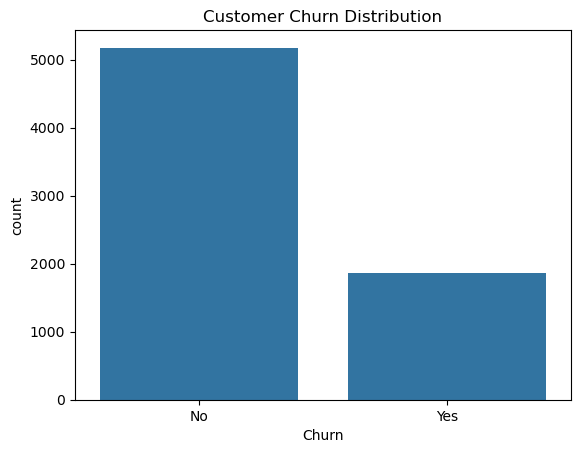

In [5]:
# ================================
# CHURN DISTRIBUTION
# ================================

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

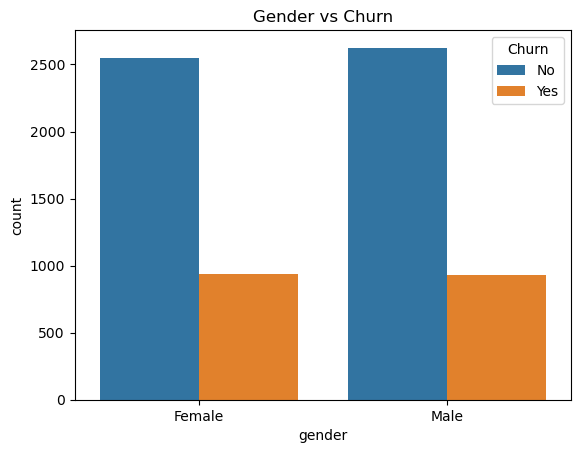

In [6]:
# ================================
# GENDER VS CHURN
# ================================

sns.countplot(x='gender', hue='Churn', data=df)

plt.title("Gender vs Churn")

plt.show()

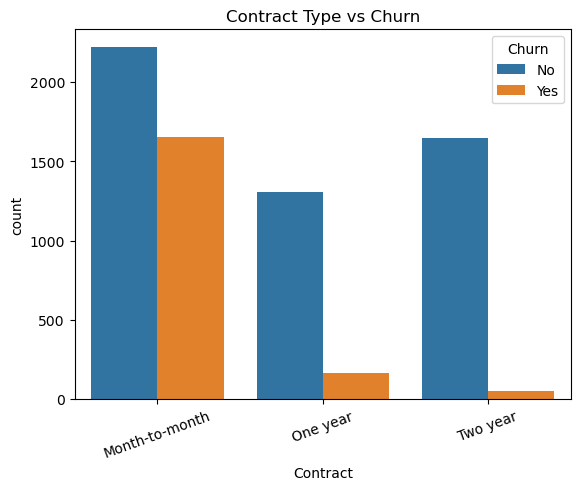

In [7]:
# ================================
# CONTRACT VS CHURN
# ================================

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=20)

plt.show()

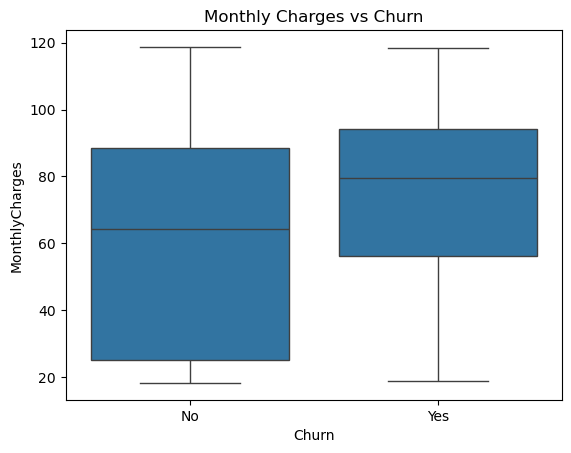

In [8]:
# ================================
# MONTHLY CHARGES VS CHURN
# ================================

sns.boxplot(x='Churn',
            y='MonthlyCharges',
            data=df)

plt.title("Monthly Charges vs Churn")

plt.show()

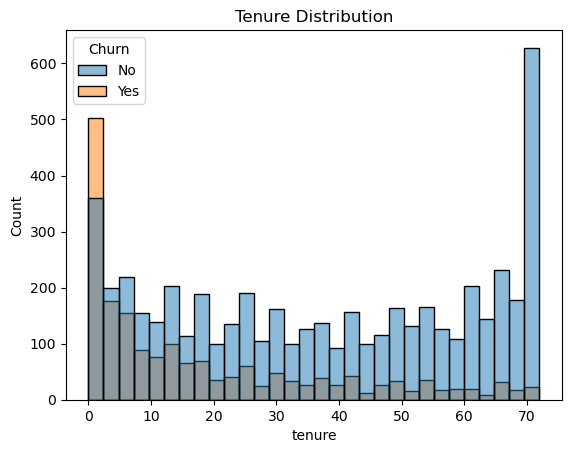

In [9]:
# ================================
# TENURE ANALYSIS
# ================================

sns.histplot(data=df,
             x='tenure',
             hue='Churn',
             bins=30)

plt.title("Tenure Distribution")

plt.show()

In [10]:
# ================================
# CREATE CHURN BINARY
# ================================

df['Churn_Binary'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

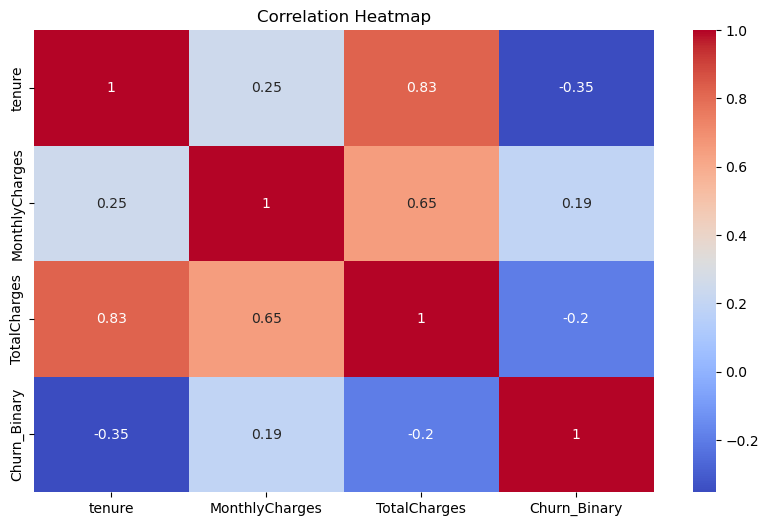

In [11]:
# ================================
# CORRELATION HEATMAP
# ================================

plt.figure(figsize=(10,6))

corr_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn_Binary'
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
# ================================
# PREPARE ML DATASET
# ================================

ml_df = df.drop('customerID', axis=1)

In [13]:
# ================================
# ENCODE CATEGORICAL VARIABLES
# ================================

ml_df = pd.get_dummies(
    ml_df,
    drop_first=True
)

In [14]:
# ================================
# DEFINE FEATURES & TARGET
# ================================

X = ml_df.drop('Churn_Binary', axis=1)

y = ml_df['Churn_Binary']

In [15]:
# ================================
# TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# ================================
# FEATURE SCALING
# ================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [17]:
# ================================
# LOGISTIC REGRESSION MODEL
# ================================

model = LogisticRegression(max_iter=2000)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [18]:
# ================================
# PREDICTIONS
# ================================

y_pred = model.predict(X_test_scaled)

In [19]:
# ================================
# MODEL ACCURACY
# ================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [20]:
# ================================
# CONFUSION MATRIX
# ================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1036    0]
 [   0  373]]


In [21]:
# ================================
# CLASSIFICATION REPORT
# ================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1036
           1       1.00      1.00      1.00       373

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



In [22]:
# ================================
# FEATURE IMPORTANCE
# ================================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance.head(10))

                           Feature  Coefficient
31                       Churn_Yes     5.850453
11     InternetService_Fiber optic     0.171710
29  PaymentMethod_Electronic check     0.088955
1                   MonthlyCharges     0.075716
27            PaperlessBilling_Yes     0.072898
24             StreamingMovies_Yes     0.061790
10               MultipleLines_Yes     0.051142
5                SeniorCitizen_Yes     0.043005
22                 StreamingTV_Yes     0.041014
9   MultipleLines_No phone service     0.023641


In [23]:
# ================================
# RANDOM FOREST MODEL
# ================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 1.0


In [24]:
# ================================
# CHURN PROBABILITY
# ================================

probabilities = model.predict_proba(X_test_scaled)

risk_scores = probabilities[:,1]

In [25]:
# ================================
# RISK SEGMENTATION
# ================================

risk_category = []

for score in risk_scores:

    if score > 0.7:
        risk_category.append("High Risk")

    elif score > 0.4:
        risk_category.append("Medium Risk")

    else:
        risk_category.append("Low Risk")

In [26]:
# ================================
# CREATE POWER BI DATASET
# ================================

powerbi_results = df.loc[X_test.index].copy()

powerbi_results['Actual_Churn'] = y_test.values

powerbi_results['Predicted_Churn'] = y_pred

powerbi_results['Churn_Probability'] = risk_scores

powerbi_results['Risk_Category'] = risk_category

In [27]:
# ================================
# HIGH RISK CUSTOMERS
# ================================

high_risk = powerbi_results[
    powerbi_results['Risk_Category'] == 'High Risk'
]

print(high_risk.head())

      customerID  gender SeniorCitizen Partner Dependents  tenure  \
185   1024-GUALD  Female            No     Yes         No       1   
1807  6910-HADCM  Female            No      No         No       1   
1263  6818-WOBHJ  Female           Yes     Yes         No      68   
811   4853-RULSV    Male            No      No         No      70   
2526  5766-ZJYBB    Male            No      No         No       1   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
185            No  No phone service             DSL                   No  ...   
1807          Yes                No     Fiber optic                   No  ...   
1263          Yes               Yes     Fiber optic                   No  ...   
811           Yes               Yes     Fiber optic                  Yes  ...   
2526          Yes                No              No  No internet service  ...   

     MonthlyCharges TotalCharges Churn EstimatedLifetimeValue TenureGroup  \
185           24.80  

In [28]:
# ================================
# RISK CATEGORY COUNTS
# ================================

print(
    powerbi_results['Risk_Category']
    .value_counts()
)

Risk_Category
Low Risk     1036
High Risk     373
Name: count, dtype: int64


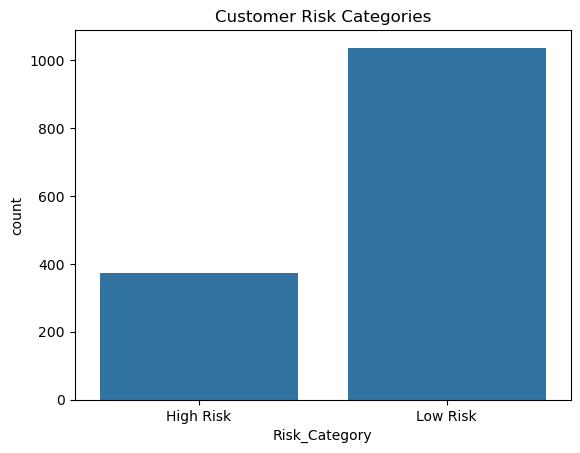

In [29]:
# ================================
# RISK CATEGORY VISUALIZATION
# ================================

sns.countplot(
    x='Risk_Category',
    data=powerbi_results
)

plt.title("Customer Risk Categories")

plt.show()

In [30]:
# ================================
# TOP HIGH RISK CUSTOMERS
# ================================

top_risk = powerbi_results.sort_values(
    by='Churn_Probability',
    ascending=False
)

print(top_risk.head(10))

      customerID  gender SeniorCitizen Partner Dependents  tenure  \
1410  7024-OHCCK  Female           Yes      No         No       2   
4800  9300-AGZNL    Male           Yes      No         No       1   
2208  7216-EWTRS  Female           Yes     Yes         No       1   
2191  3988-RQIXO  Female           Yes      No         No       1   
2577  4910-GMJOT  Female            No      No         No       1   
2184  4695-WJZUE  Female           Yes      No         No       2   
585   5192-EBGOV  Female           Yes      No         No       1   
3078  5277-ZLOOR  Female           Yes      No         No       2   
1600  3068-OMWZA    Male           Yes      No         No       1   
3467  8414-MYSHR    Male           Yes      No         No       5   

     PhoneService MultipleLines InternetService OnlineSecurity  ...  \
1410          Yes           Yes     Fiber optic             No  ...   
4800          Yes           Yes     Fiber optic             No  ...   
2208          Yes          

In [31]:
# ================================
# EXPORT POWER BI DATASET
# ================================

powerbi_results.to_csv(
    "powerbi_churn_dashboard.csv",
    index=False
)

print("Power BI dataset exported successfully.")

Power BI dataset exported successfully.
